In [1]:
pip install google-generativeai pillow langchain-chroma

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
  Using cached googleapis_common_protos-1.75.0-py3-none-any.whl.metadata (8.6 kB)
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 2.3 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 2.1 MB/s  0:00:0


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import ollama
def ask_llm(prompt):
    response = ollama.chat(
        model = "llama3:8b",
        messages = [{
            "role" : "user",
            "content" : prompt
        }],
        stream = true
    )
    for res in response:
        print(res['messages']['content'],end="",flush = True)

In [ ]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://text-generation.yaminisakhalabhaktula06.workers.dev/",
        headers={
            "Authorization": "Bearer your_api_key",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )
    data = response.json()
    print(data['response'])
    return data['response']

In [86]:
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption
)
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True
pipeline_options.generate_page_images = True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

PDF_PATH = r"C:\Users\deepa\Documents\AI.pdf"
result = converter.convert(PDF_PATH)

doc = result.document


[INFO] 2026-06-17 23:32:51,815 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-17 23:32:51,828 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\deepa\AppData\Roaming\Python\Python314\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-17 23:32:51,830 [RapidOCR] main.py:65: Using C:\Users\deepa\AppData\Roaming\Python\Python314\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-17 23:32:52,099 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-17 23:32:52,104 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\deepa\AppData\Roaming\Python\Python314\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-17 23:32:52,106 [RapidOCR] main.py:65: Using C:\Users\deepa\AppData\Roaming\Python\Python314\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-17 23:32:52,209 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[PictureItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/14'), RefItem(cref='#/texts/15'), RefItem(cref='#/texts/16'), RefItem(cref='#/texts/17'), RefItem(cref='#/texts/18'), RefItem(cref='#/texts/19'), RefItem(cref='#/texts/20'), RefItem(cref='#/texts/21'), RefItem(cref='#/texts/22'), RefItem(cref='#/texts/23'), RefItem(cref='#/texts/24'), RefItem(cref='#/texts/25'), RefItem(cref='#/texts/26'), RefItem(cref='#/texts/27'), RefItem(cref='#/texts/28'), RefItem(cref='#/texts/29'), RefItem(cref='#/texts/30'), RefItem(cref='#/texts/31'), RefItem(cref='#/texts/32'), RefItem(cref='#/texts/33'), RefItem(cref='#/texts/34'), RefItem(cref='#/texts/35'), RefItem(cref='#/texts/36'), RefItem(cref='#/texts/37'), RefItem(cref='#/texts/38'), RefItem(cref='#/texts/39'), RefItem(cref='#/texts/40')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.PICTURE: 'picture'>, prov=[ProvenanceItem(page_no=2, bbox=BoundingBox(l=103.18091583251953
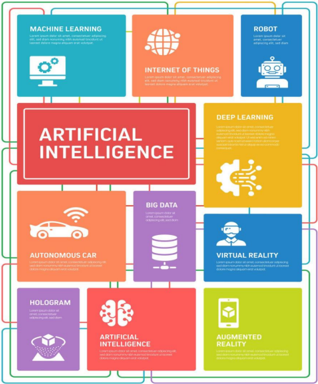

In [87]:
doc.pictures

In [88]:
print(len(doc.pictures))

1


In [89]:
from docling.chunking import HybridChunker
chunker=HybridChunker()
chunks=list(chunker.chunk(dl_doc=doc))

In [90]:
print(len(chunks))

6


In [91]:
pip install google-generativeai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
pip install -U google-genai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import google.generativeai as genai

genai.configure(api_key="AQ.Ab8RN6I_se4TryDD_tt5OdBeUEm4RZCP4_Br6VDuavw8NXGYJw")

model = genai.GenerativeModel("gemini-2.5-flash")

In [94]:
def summarize_chunk(chunk):
    TEXT_PROMPT = f"""
Summarize the following chunk.
Preserve important names, numbers and facts.
Return only the summary.

Chunk:
{chunk}
"""
    return generate_response(TEXT_PROMPT)

In [95]:
IMAGE_PROMPT = """
Generate a comprehensive semantic description of this image for use in a multimodal retrieval system.

Describe all visible content including:
- Titles and headings
- Objects and entities
- Text and numbers
- Tables and charts
- Axes, legends and units
- Diagrams and flowcharts
- Relationships between components
- Colors and layout when important
- Statistics and measurements
- Technical terminology
- Key conclusions and insights

Preserve names, dates, values, and identifiers exactly.

Produce a detailed, self-contained description so that a user can answer questions about the image without directly seeing it.

Return only the description.
"""

In [96]:
def summarize_image(image):

    response = model.generate_content(
        [
            IMAGE_PROMPT,
            image
        ]
    )

    print(response.text)

    return response.text

In [97]:
documents = []
from langchain_core.documents import Document

In [98]:
from langchain_core.documents import Document

documents = []

for chunk in chunks:
    print("chunked")
    summary = summarize_chunk(str(chunk.text))

    documents.append(
        Document(
            page_content=summary,
            metadata={
                "type": "text"
            }
        )
    )

chunked
Artificial Intelligence (AI) is a computer science branch that creates machines to perform human-like tasks, including learning and decision-making, and is widely used in applications such as virtual assistants, healthcare, and banking.
chunked
Narrow AI performs specific tasks efficiently, with examples including voice assistants, facial recognition systems, and recommendation engines used by online platforms.
chunked
General AI refers to machines that can perform any intellectual task a human can, learning and applying knowledge across domains, but it remains under research and has not been achieved yet.
chunked
Super AI is a hypothetical AI form that would surpass human intelligence in aspects like creativity, decision-making, and problem-solving, and remains a theoretical future concept.
chunked
AI offers several benefits, including increased productivity, reduced human errors, and improved efficiency, by automating tasks, processing large amounts of information quickly, an

In [99]:
pip install -U google-generativeai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
len(documents)


6

In [101]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="mixedbread-ai/mxbai-embed-large-v1",
)

C:\Users\deepa\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\deepa\.cache\huggingface\hub\models--mixedbread-ai--mxbai-embed-large-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [103]:
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="multimodal_rag",
    persist_directory="./chroma_mragdb",
    embedding_function=embeddings
)

In [104]:
vectorstore._collection.count()

0

In [105]:
vectorstore.add_documents(documents)

['23fe8fa8-cd94-4297-b8c6-26db4397a3df',
 'bb5f5069-3f30-4170-93c3-7e342e058fb8',
 'ac2ada54-e972-4798-9478-aef48a51f7be',
 '7910f33f-763b-42bf-bf3b-4636961813f7',
 'd7ff1aea-5159-4cdc-9b4c-c0fd34ff144a',
 'aefa6838-138c-4507-b718-41219d42110b']

In [111]:
vectorstore._collection.count()

6

In [112]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":20,
        "fetch_k":50
    }
)

In [114]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "BAAI/bge-reranker-large",
)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [115]:
def retrieve(query, top_k=5):

    docs = retriever.invoke(query)

    pairs = [
        [query, doc.page_content]
        for doc in docs
    ]

    scores = reranker.predict(pairs)

    ranked_docs = sorted(
        zip(scores, docs),
        key=lambda x: x[0],
        reverse=True
    )

    return [
        doc
        for score, doc in ranked_docs[:top_k]
    ]

In [116]:
def build_context(query):

    retrieved_docs = retrieve(query)

    context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    return context

In [117]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://text-generation.niroshanukala.workers.dev/",
        headers={
            "Authorization": "Bearer 12345678",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )

    return response.json()

In [118]:
def ask(query):

    context = build_context(query)
    print(f"The context retrived is:{context}")

    prompt = f"""
You are a helpful assistant.

Answer the question using ONLY the context below.

If the answer is not present, say:
'I could not find the answer in the provided context.'

Context:
{context}

Question:
{query}

Answer:
"""

    return generate_response(prompt)

In [119]:
answer = ask(
    "What is the problem statement give me in a single line"
)

print(answer)

The context retrived is:Artificial Intelligence (AI) is a computer science branch that creates machines to perform human-like tasks, including learning and decision-making, and is widely used in applications such as virtual assistants, healthcare, and banking.

Narrow AI performs specific tasks efficiently, with examples including voice assistants, facial recognition systems, and recommendation engines used by online platforms.

AI has several challenges, including requiring large amounts of data and computational resources, raising privacy and security concerns, potentially producing biased results, leading to job displacement, and posing ethical concerns regarding accountability and decision-making.

General AI refers to machines that can perform any intellectual task a human can, learning and applying knowledge across domains, but it remains under research and has not been achieved yet.

AI offers several benefits, including increased productivity, reduced human errors, and improved

In [120]:
from transformers import AutoTokenizer
from docling.chunking import HybridChunker

tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [121]:
chunker = HybridChunker(
    tokenizer=tokenizer,
    max_tokens=1024
)

chunks = list(chunker.chunk(dl_doc=doc))

In [122]:
len(chunks)

6